# Breast Cancer Classification using Logistic Regression

### This script loads a breast cancer dataset, processes the data, trains a logistic regression model, and uses user input to predict whether a breast tumor is malignant or benign.
### Visualization of the data and model performance metrics is also provided.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

## Step 1: Load the dataset

In [2]:
# Load the breast cancer dataset from a CSV file.
file = pd.read_csv('Breast_cancer_dataset.csv')

In [3]:
# Convert the file into a dataframe for easier manipulation
breast_dataset = pd.DataFrame(file)

## Step 2: Initial Dataset Inspection

In [4]:
# Display basic information about the dataset to understand its structure
print("### Dataset Information:")
breast_dataset.info()  # Shows the number of columns, non-null values, and data types

### Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  p

In [5]:
# Show the first 5 rows of the dataset for a quick overview
print("\n### First 5 Rows of the Dataset:")
print(breast_dataset.head())  # Displays the top 5 rows of the dataset


### First 5 Rows of the Dataset:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perim

In [6]:
# Check for missing values in each column
print("\n### Null Value Check:")
breast_dataset.isnull().sum()  # This will display the count of missing values per column


### Null Value Check:


id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

## Step 3: Data Cleaning

In [7]:
# Drop unnecessary columns such as 'id' and 'Unnamed: 32' (if they exist) that don't contribute to the model
breast_dataset = breast_dataset.drop(['id', 'Unnamed: 32'], axis=1, errors='ignore')

In [8]:
# Display the dataset information again to ensure unnecessary columns have been removed
print("\n### Dataset Information After Dropping Columns:")
breast_dataset.info()


### Dataset Information After Dropping Columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 no

## Step 4: Encoding the Target Variable

In [9]:
# Convert the 'diagnosis' column to numerical values: M (Malignant) = 1, B (Benign) = 0
breast_dataset['diagnosis'] = breast_dataset['diagnosis'].apply(lambda x: 1 if x == 'M' else 0)

## Step 5: Data Preprocessing

In [10]:
# Split the dataset into features (X) and the target variable (y)
X = breast_dataset.drop('diagnosis', axis=1)  # Features (independent variables)
y = breast_dataset['diagnosis']  # Target variable (dependent variable)

In [11]:
# Standardize the features using StandardScaler to normalize the data for better performance of the model
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)  # Scaling ensures all features are on a similar scale

## Step 6: Split the Data into Training and Testing Sets

In [12]:
# Split the data into 70% training data and 30% testing data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

## Step 7: Train the Logistic Regression Model

In [13]:
# Initialize the logistic regression model
model = LogisticRegression(random_state=42)

In [14]:
# Train the model using the training data
model.fit(X_train, y_train)

LogisticRegression(random_state=42)

# Visualizations

## Step 8: Visualization of Target Variable Distribution


### Visualization: Target Variable Distribution


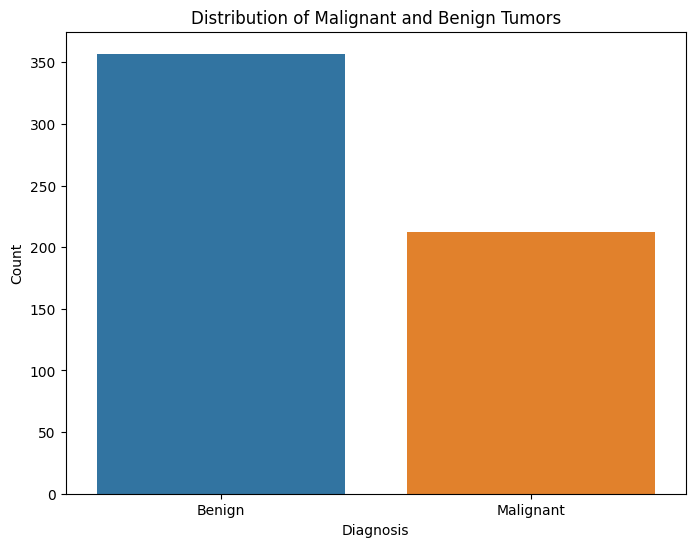

In [15]:
print("\n### Visualization: Target Variable Distribution")
plt.figure(figsize=(8,6))
sns.countplot(x='diagnosis', data=breast_dataset, hue='diagnosis', legend=False)
plt.title('Distribution of Malignant and Benign Tumors')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Benign', 'Malignant'])
plt.show()

## Step 9: Visualization of Feature Distributions

### Visualization: Feature Distributions


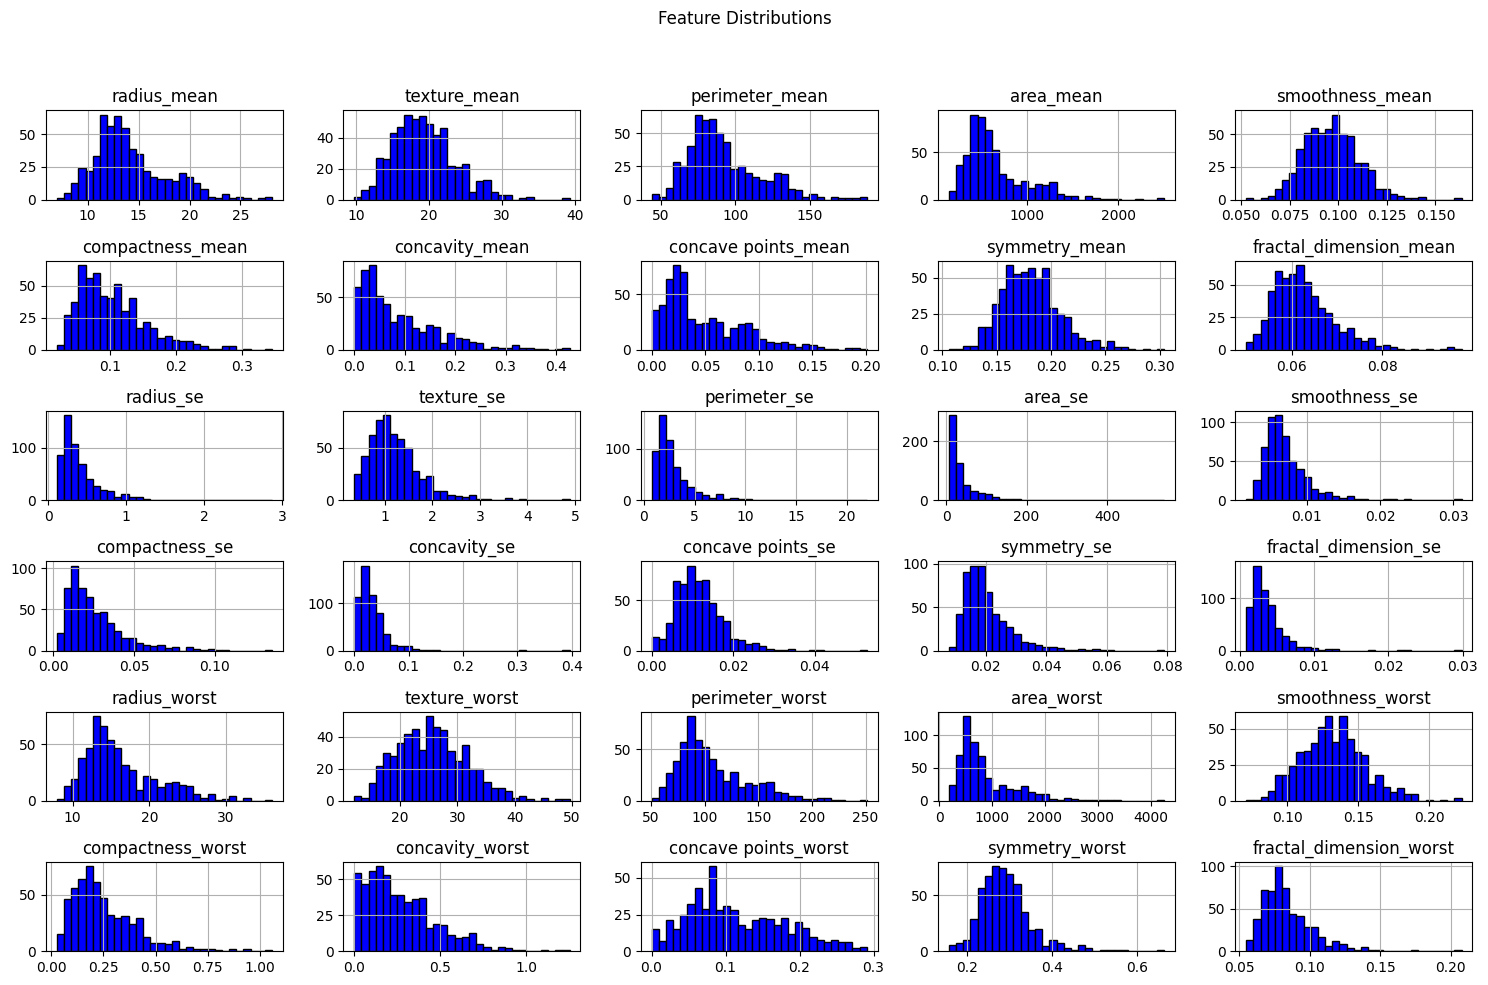

In [16]:
print("### Visualization: Feature Distributions")
breast_dataset.drop('diagnosis', axis=1).hist(bins=30, figsize=(15, 10), color='blue', edgecolor='black')
plt.suptitle('Feature Distributions')
plt.tight_layout(rect=[0, 0, 1, 0.95]) 
plt.show()

## Step 10: Feature Correlation Heatmap

### Visualization: Feature Correlation Heatmap


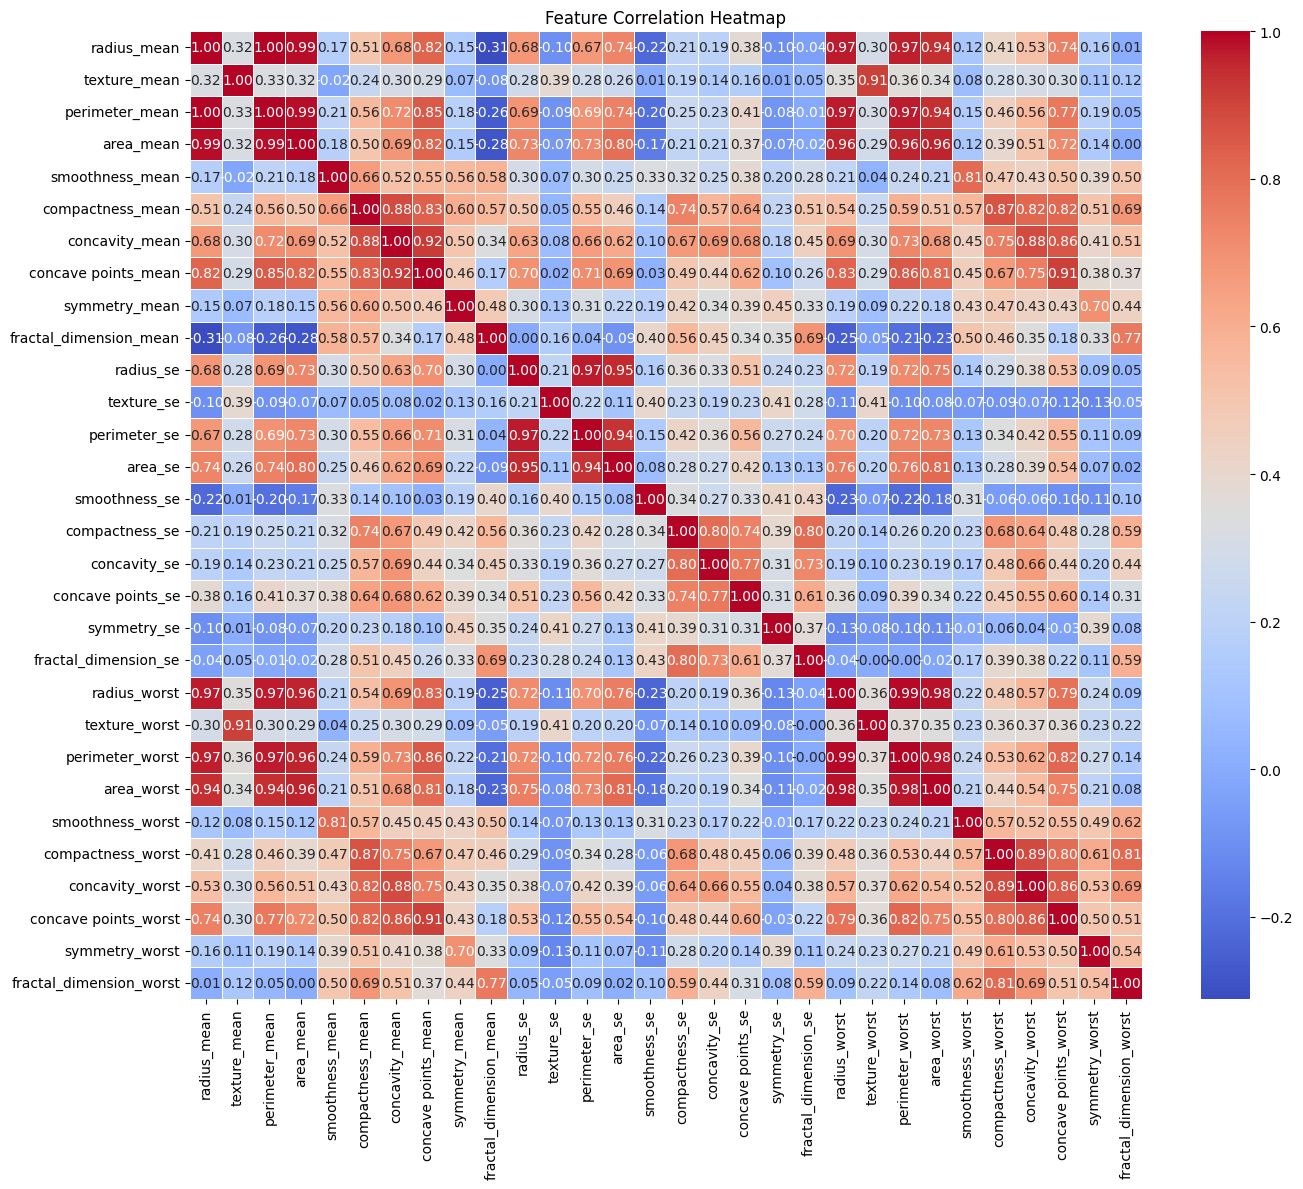

In [17]:
print("### Visualization: Feature Correlation Heatmap")
plt.figure(figsize=(14,12))   # Set figure size for better readability
sns.heatmap(breast_dataset.drop('diagnosis', axis=1).corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, annot_kws={"size": 10} )
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Step 11: Function to Make Predictions Based on User Input

In [18]:
def user_input_prediction():
    print("\n### Enter the following feature values for prediction ###\n")
    
    user_data = []
    for feature in X.columns:  # Ensure feature names are consistent
        while True:
            try:
                value = float(input(f"Enter value for {feature}: "))
                user_data.append(value)
                break
            except ValueError:
                print("Invalid input. Please enter a numeric value.")

    user_data = pd.DataFrame([user_data], columns=X.columns)  # Maintain feature names
    user_data_scaled = scaler.transform(user_data)  # Use the same scaler
    prediction = model.predict(user_data_scaled)
    
    return 'Malignant' if prediction == 1 else 'Benign'

# Main Program

### Breast Cancer Classification Model (Logistic Regression) ###

### Dataset Overview:
   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radiu

Enter value for radius_mean:  15
Enter value for texture_mean:  15
Enter value for perimeter_mean:  90
Enter value for area_mean:  700
Enter value for smoothness_mean:  0.1
Enter value for compactness_mean:  0.2
Enter value for concavity_mean:  0.3
Enter value for concave points_mean:  0.4
Enter value for symmetry_mean:  0.5
Enter value for fractal_dimension_mean:  0.1
Enter value for radius_se:  1.2
Enter value for texture_se:  2.1
Enter value for perimeter_se:  1.5
Enter value for area_se:  10
Enter value for smoothness_se:  0.05
Enter value for compactness_se:  0.03
Enter value for concavity_se:  0.04
Enter value for concave points_se:  0.02
Enter value for symmetry_se:  0.04
Enter value for fractal_dimension_se:  0.02
Enter value for radius_worst:  20
Enter value for texture_worst:  25
Enter value for perimeter_worst:  120
Enter value for area_worst:  1000
Enter value for smoothness_worst:  0.12
Enter value for compactness_worst:  0.25
Enter value for concavity_worst:  0.3
Enter va

----------------------------------------------------------


### The prediction based on your input is: Malignant

### Confusion Matrix


C:\Users\sarfaraz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


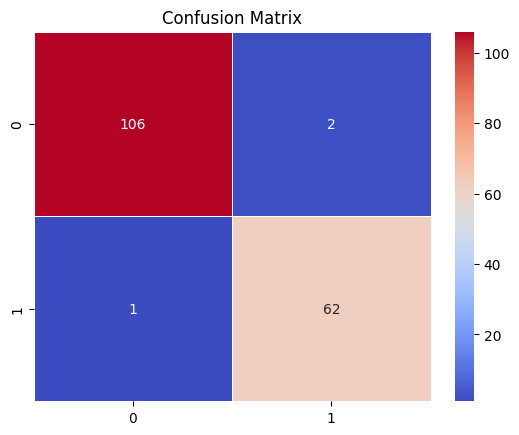


### Classification Report
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       108
           1       0.97      0.98      0.98        63

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



In [19]:
if __name__ == '__main__':
    print("### Breast Cancer Classification Model (Logistic Regression) ###\n")

    # Dataset Overview
    print("### Dataset Overview:")
    print(breast_dataset.head())

    # Get Prediction from User Input
    prediction = user_input_prediction()
    print(f"----------------------------------------------------------\n")
    print(f"\n### The prediction based on your input is: {prediction}\n")

    # Confusion Matrix for Model Performance
    X_test_df = pd.DataFrame(X_test, columns=X.columns)

    # Predict using the model
    y_pred = model.predict(X_test_df)

    # Print and plot the confusion matrix
    print("### Confusion Matrix")
    conf_matrix = confusion_matrix(y_test, y_pred)
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="coolwarm", linewidths=0.5)
    plt.title("Confusion Matrix")
    plt.show()

    # Model Performance - Classification Report
    print("\n### Classification Report")
    print(classification_report(y_test, y_pred))  